# Weighted K-Nearest Neighbor
Missing Values Imputation menggunakan Weighted K-Nearest Neighbor (WKNN)

*Hasil Excel*

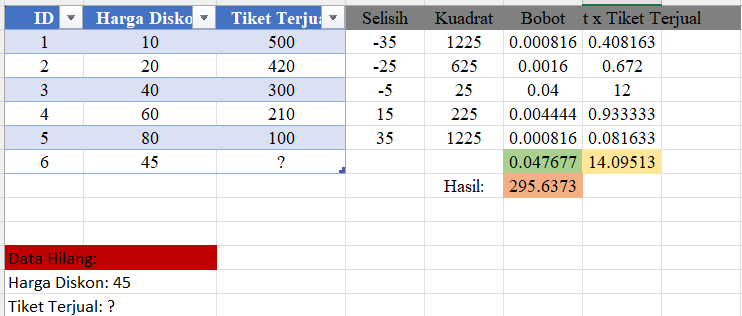

### 1. Dataset
|   ID  |  Harga Diskon   |  Tiket Terjual  |  
| ----- | --------------  | --------------- |
|   1   |      10         |       500       |
|   2   |      20         |       420       |
|   3   |      40         |       300       |
|   4   |      60         |       210       |
|   5   |      80         |       100       |
|   6   |      46         |         ?       |

*Data Target*
- Harga Diskon: 45
- Tiket terjual: ?

### 2. Hitung Jarak
Menggunakan jarak Euclidean untuk mengukur kedekatan antara harga diskon pada dataset dengan harga target (45).


$
d(x_i, x_j) = (x_i - x_j)^2
$


Keterangan:
-  $d$  → Nilai jarak kuadrat hasil perhitungan.
-  $x_i$  → Harga diskon yang ada di data.
-  $x_j$  → Harga target yang ingin dicari (45).
-  $(...)^2$  → Pangkat dua untuk memastikan hasil selalu positif.

|   Tetangga(Harga)  |  Selisih   |  Kuadrat  |  
| ------------------ | ---------- | --------- |
|         10         |    -35     |    1225   |
|         20         |    -25     |     625   |
|         40         |     -5     |     25    |
|         60         |     15     |     225   |
|         80         |     35     |    1225   |

### 3. Hitung Kemiripan
Menggunakan rumus bobot untuk menentukan seberapa besar pengaruh setiap data tetangga terhadap estimasi data yang hilang.


$$
w = \frac{1}{d}
$$


Keterangan:
-  $w$  → Weight/Bobot
-  $d$  → Distance/Jarak
- 1 → konstanta

|   Harga Diskon  |  Tiket Terjual |   Bobot   |  
| --------------- | -------------- | --------- |
|        10       |      500       | 0.000816  |
|        20       |      420       | 0.0016    |
|        40       |      300       | 0.04      |
|        60       |      210       | 0.004444  |
|        80       |      100       | 0.000816  |

### 4. Weighted Average

*Pembilang (Total Bobot x Tiket Terjual):*

(0.000816 × 500) + (0.0016 × 420) + (0.04 × 300) + (0.004444 × 210) + (0.000816 × 100)
- Hasil: 14.09513

*Penyebut (Total Bobot):*

0.000816 + 0.0016 + 0.04 + 0.004444 + 0.000816
- Hasil: 0.047677


### 5. Hasil Estimasi


$$\text{Nilai} = \frac{14,09513}{0,047677}$$


$$\approx 295,641151$$

In [1]:
harga = [10, 20, 40, 60, 80]
tiket = [500, 420, 300, 210, 100]

target = 45

print("DATASET")
print("Harga Diskon :", harga)
print("Tiket Terjual :", tiket)
print("Target Harga  :", target)
print()

DATASET
Harga Diskon : [10, 20, 40, 60, 80]
Tiket Terjual : [500, 420, 300, 210, 100]
Target Harga  : 45



## A. Hitung Selisih
Data harga yang digunakan: [10, 20, 40, 60, 80] dengan target 45.
*Proses Pengurangan:*
- 10 - 45 = -35
- 20 - 45 = -25
- 40 - 45 = -5
- 60 - 45 = 15
- 80 - 45 = 35

Bagian ini bertujuan untuk mengukur rentang atau jarak linear antara setiap harga di dataset dengan harga target (45). Selisih ini memberi tahu kita posisi data; jika hasilnya negatif berarti di bawah target, dan jika positif berarti di atas target.

In [2]:
# List harga dan target
harga = [10, 20, 40, 60, 80]
target = 45

# Menghitung selisih satu per satu
selisih = []
for h in harga:
    hasil = h - target
    selisih.append(hasil)

print("Hasil Selisih (Harga - Target):")
print(selisih)

Hasil Selisih (Harga - Target):
[-35, -25, -5, 15, 35]


## B. Hitung kuadrat jarak
selisih = [-35, -25, -5, 15, 35]


$$\begin{aligned} (-35)^2 &= 1225 \\ (-25)^2 &= 625 \\ (-5)^2 &= 25 \\ 15^2 &= 225 \\ 35^2 &= 1225 \end{aligned}$$


Setelah selisih didapat, angka-angka tersebut dipangkatkan dua untuk menghilangkan tanda negatif agar semua jarak menjadi bernilai positif (absolut).

In [3]:
# Menghitung kuadrat untuk setiap elemen dalam list selisih
hasil_kuadrat = [n**2 for n in selisih]

print("Daftar Jarak Kuadrat:")
print(hasil_kuadrat)

Daftar Jarak Kuadrat:
[1225, 625, 25, 225, 1225]


## C. Hitung bobot / kemiripan

Berikut adalah rincian pembagian nilai berdasarkan jarak kuadrat untuk mencari tingkat kemiripan:


$$\frac{1}{1225} = 0.000816$$$$\frac{1}{625} = 0.0016$$$$\frac{1}{25} = 0.04$$$$\frac{1}{225} = 0.004444$$$$\frac{1}{1225} = 0.000816$$



Inti dari tahap ini adalah membalik nilai jarak menjadi bobot. Data yang jaraknya paling kecil (paling dekat dengan harga 45) secara otomatis akan mendapatkan nilai bobot paling besar. Dengan begitu, data yang paling mirip akan memberikan pengaruh paling kuat pada hasil prediksi akhir nanti.

In [4]:
# 1. Definisikan selisih
selisih = [-35, -25, -5, 15, 35]

# 2. Hitung kuadrat
kuadrat = [s**2 for s in selisih]

# 3. Hitung bobot
hasil_bobot = []
for d in kuadrat:
    if d != 0:
        w = round(1 / d, 6)
        hasil_bobot.append(w)
    else:
        hasil_bobot.append(1.0)

print("Hasil Kuadrat:", kuadrat)
print("Hasil Bobot  :", hasil_bobot)

Hasil Kuadrat: [1225, 625, 25, 225, 1225]
Hasil Bobot  : [0.000816, 0.0016, 0.04, 0.004444, 0.000816]


## D. Hitung bobot × nilai
Setelah nilai bobot didapat, langkah selanjutnya adalah mengalikan bobot tersebut dengan jumlah tiket terjual dari masing-masing data.


$$0.000816 \times 500 = 0.408163$$$$0.0016 \times 420 = 0.672$$$$0.04 \times 300 = 12$$$$0.004444 \times 210 = 0.933333$$$$0.000816 \times 100 = 0.081633$$


Data yang memiliki bobot besar akan menyumbangkan angka yang lebih signifikan terhadap hasil prediksi. Sebaliknya, data yang jauh hanya akan memberikan kontribusi nilai yang kecil.

In [5]:
# 1. Data dari tabel
bobot = [0.000816, 0.0016, 0.04, 0.004444, 0.000816]
tiket = [500, 420, 300, 210, 100]

bobot_nilai = []

# 3. Hitung dan tampilkan
for i in range(len(tiket)):
    hasil = bobot[i] * tiket[i]
    bobot_nilai.append(hasil)
    print(f"{bobot[i]} * {tiket[i]} = {hasil}")

print("\nBOBOT x NILAI")
print(bobot_nilai)

0.000816 * 500 = 0.408
0.0016 * 420 = 0.672
0.04 * 300 = 12.0
0.004444 * 210 = 0.93324
0.000816 * 100 = 0.0816

BOBOT x NILAI
[0.408, 0.672, 12.0, 0.93324, 0.0816]


## E. Hitung nilai Pembilang
Pada tahap ini, merupakan proses menjumlahkan seluruh hasil perkalian antara bobot dan jumlah tiket yang telah dihitung sebelumnya.


$$Pembilang = 0.408163 + 0.672 + 12 + 0.933333 + 0,081633$$$$Pembilang = 14.09513$$


Pembilang merupakan total nilai terbobot yang akan digunakan sebagai angka utama dalam menentukan estimasi akhir.

In [6]:
# 1. Data
ID = [1, 2, 3, 4, 5]
tiket_terjual = [500, 420, 300, 210, 100]
kuadrat = [1225, 625, 25, 225, 1225]

# List untuk menampung hasil b x Tiket Terjual
bobot_tiket = []

# 2. Proses hitung perkalian
for i in range(len(tiket_terjual)):
    # Bobot adalah 1 dibagi kuadrat
    bobot = 1 / kuadrat[i]
    hasil = bobot * tiket_terjual[i]
    bobot_tiket.append(hasil)

    print(f"ID {ID[i]}: ({bobot:.7f}) * {tiket_terjual[i]} = {hasil:.6f}")

total_pembilang = sum(bobot_tiket)

print("HASIL AKUMULASI PEMBILANG:")
print(f"{total_pembilang:.5f}")

ID 1: (0.0008163) * 500 = 0.408163
ID 2: (0.0016000) * 420 = 0.672000
ID 3: (0.0400000) * 300 = 12.000000
ID 4: (0.0044444) * 210 = 0.933333
ID 5: (0.0008163) * 100 = 0.081633
HASIL AKUMULASI PEMBILANG:
14.09513


## F. Hitung Nilai Penyebut
Tahap ini dilakukan dengan menjumlahkan seluruh nilai bobot ($w$) yang telah diperoleh untuk digunakan sebagai pembagi pada langkah akhir.


$$Penyebut = 0,000816 + 0,0016 + 0,04 + 0,004444 + 0,000816$$$$Penyebut = 0,047677$$


Penyebut ini merepresentasikan total kontribusi dari seluruh tetangga terdekat yang digunakan dalam perhitungan. Nilai ini sangat penting untuk menormalisasi hasil prediksi agar angka akhirnya tetap berada dalam skala yang logis (rata-rata terbobot). Dengan membagi pembilang menggunakan total penyebut ini, maka akan mendapatkan estimasi jumlah tiket terjual yang paling mendekati kenyataan berdasarkan kedekatan harga.

In [7]:
# data
kuadrat = [1225, 625, 25, 225, 1225]

hasil_bobot = []
for k in kuadrat:
    hasil_bobot.append(1 / k)

total_penyebut = sum(hasil_bobot)

print("NILAI TOTAL PENYEBUT:")
print(f"{total_penyebut:.6f}")

NILAI TOTAL PENYEBUT:
0.047677


## G. Estimasi Nilai
Hasil akhir didapatkan dengan membagi total pembilang (nilai terbobot) dengan total penyebut (akumulasi bobot):


$$\text{Estimasi} = \frac{\text{Total Pembilang}}{\text{Total Penyebut}}$$$$\text{Estimasi} = \frac{14,09513}{0,047677}$$$$\text{Estimasi} = 295,6373$$


Hasil akhir menunjukkan bahwa pada target harga 45, estimasi tiket yang terjual adalah sebanyak 295,6373 (atau dapat dibulatkan menjadi 296 tiket).

In [8]:
# 1. Ambil data asli (tanpa pembulatan manual)
kuadrat = [1225, 625, 25, 225, 1225]
tiket = [500, 420, 300, 210, 100]

# 2. Hitung Pembilang dan Penyebut secara otomatis
hasil_bobot = [1/k for k in kuadrat]
hasil_kali = [(1/kuadrat[i]) * tiket[i] for i in range(len(tiket))]

pembilang_akurat = sum(hasil_kali)
penyebut_akurat = sum(hasil_bobot)

# 3. Hitung Estimasi Final
estimasi_final = pembilang_akurat / penyebut_akurat

print(f"Total Pembilang : {pembilang_akurat:.6f}")
print(f"Total Penyebut  : {penyebut_akurat:.6f}")
print(f"ESTIMASI NILAI  : {estimasi_final:.4f}")

Total Pembilang : 14.095129
Total Penyebut  : 0.047677
ESTIMASI NILAI  : 295.6373


## Normalisasi Data
Normalisasi data adalah proses transformasi untuk menyamakan skala nilai pada setiap variabel dalam sebuah dataset. Tujuannya adalah agar semua atribut berada dalam rentang yang seragam tanpa menghilangkan pola distribusi data aslinya.

Dalam algoritma yang menggunakan perhitungan jarak, seperti Weighted K-Nearest Neighbor (WKNN), normalisasi sangat wajib dilakukan. Tanpa proses ini, variabel dengan angka yang besar (misalnya: Harga Tiket) akan mendominasi hasil perhitungan dibandingkan variabel dengan angka kecil (misalnya: Harga Diskon). Dengan normalisasi, kita memastikan setiap fitur memberikan kontribusi yang adil dan seimbang dalam menentukan hasil prediksi (menghindari bias).





*Hasil ujicoba excel*


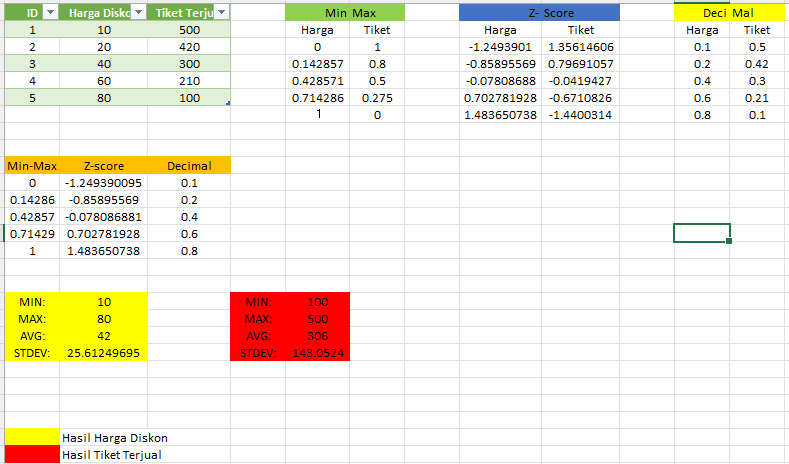


## Jenis-Jenis Normalisasi Data
Terdapat beberapa metode normalisasi yang umum digunakan dalam data mining dan machine learning, antara lain Min-Max Normalization, Z-Score Normalization, dan Decimal Scaling.

### I. Min-Max Normalization
Min-Max Normalization adalah metode normalisasi yang mengubah nilai data ke dalam rentang tertentu, biasanya antara 0 hingga 1. Metode ini dilakukan dengan mengurangi nilai data dengan nilai minimum kemudian membaginya dengan selisih antara nilai maksimum dan minimum.


*Rumus Min-Max Normalization:*


$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$


*Keterangan:*

- $x$ = nilai data asli
- $x_{min}$ = nilai minimum pada dataset
- $x_{max}$ = nilai maksimum pada dataset
- $x'$ = nilai hasil normalisasi


*Dataset*

|   Harga Diskon  |  Tiket Terjual |    
| --------------- | -------------- |
|        10       |      500       |
|        20       |      420       |
|        40       |      300       |
|        60       |      210       |
|        80       |      100       |



*Nilai Statistik*
- Nilai minimum ($x_{min}$) = 10
- Nilai maksimum ($x_{max}$) = 80

*Contoh Perhitungan*
- $x' = \frac{10 - 10}{80 - 10} = 0$
- $x' = \frac{20 - 10}{80 - 10} = 0,142857$

*Hasil Normalisasi*
|   Harga Diskon  |  Normalisasi |    
| --------------- | ------------ |
|        10       |      0       |
|        20       |   0.142857   |
|        40       |   0.428571   |
|        60       |   0.714286   |
|        80       |      1       |

In [9]:
import numpy as np

# 1. Input Data
harga = [10, 20, 40, 60, 80]
tiket = [500, 420, 300, 210, 100]

# 2. Fungsi hitung Min-Max Normalization
def tampil_minmax(nama, data):
    min_val = min(data)
    max_val = max(data)

    print(f"Min-Max {nama}:")
    for x in data:
        # Rumus: (x - min) / (max - min)
        norm = (x - min_val) / (max_val - min_val)
        print(f"{norm:.9f}")
    print()

# 3. Eksekusi
tampil_minmax("Harga Diskon", harga)
tampil_minmax("Tiket Terjual", tiket)

Min-Max Harga Diskon:
0.000000000
0.142857143
0.428571429
0.714285714
1.000000000

Min-Max Tiket Terjual:
1.000000000
0.800000000
0.500000000
0.275000000
0.000000000



### II. Z-Score Normalization (Standardization)

Z-Score Normalization mengubah data sehingga memiliki rata-rata (mean) = 0 dan standar deviasi = 1. Metode ini sering digunakan dalam machine learning karena mampu mempertahankan distribusi data.

*Rumus Z-Score:*   


$$z = \frac{x - \mu}{\sigma}$$


*Keterangan:*
- $x$ = nilai data
- $\mu$ = rata-rata data
- $\sigma$ = standar deviasi
- $z$ = nilai hasil normalisasi


*Contoh*
- Dataset Harga Diskon: 10, 20, 40, 60, 80
- Mean ($\mu$)  


$$10 + 20 + 40 + 60 + 80 = 210$$


$$210 / 5 = \mathbf{42}$$


- Standar deviasi ($\sigma$)

Kurangi setiap angka dengan 42, lalu dikuadratkan:


$$10 \rightarrow (10-42)^2 = 1024$$
$$20 \rightarrow (20-42)^2 = 484$$
$$40 \rightarrow (40-42)^2 = 4$$
$$60 \rightarrow (60-42)^2 = 324$$
$$80 \rightarrow (80-42)^2 = 1444$$


Jumlahkan hasil kuadrat, bagi 5, lalu diakar kuadrat:


$$Total Kuadrat: 1024 + 484 + 4 + 324 + 1444 = \mathbf{3280}$$
$$Bagi 5: 3280 / 5 = \mathbf{656}$$
$$Akar Kuadrat: \sqrt{656} = \mathbf{25.61249}$$


- Perhitungan


$$z = \frac{10 - 42}{25.29822} = -1.2649$$


*Tabel Hasil*

|   Harga Diskon  |    Z-Score   |    
| --------------- | ------------ |
|        10       |   -1.2649    |
|        20       |   -0.8696    |
|        40       |   -0.0790    |
|        60       |    0.7115    |
|        80       |    1.5020    |

In [10]:
import numpy as np

# 1. Input Data
harga = [10, 20, 40, 60, 80]
tiket = [500, 420, 300, 210, 100]

# 2. Fungsi hitung Z-Score
def tampil_zscore(nama, data):
    mu = np.mean(data)
    sigma = np.std(data)

    print(f"Z-Score {nama}:")
    for x in data:
        z = (x - mu) / sigma
        print(f"{z:.9f}")
    print()

# 3. Eksekusi
tampil_zscore("Harga Diskon", harga)
tampil_zscore("Tiket Terjual", tiket)

Z-Score Harga Diskon:
-1.249390095
-0.858955690
-0.078086881
0.702781928
1.483650738

Z-Score Tiket Terjual:
1.356146059
0.796910571
-0.041942662
-0.671082586
-1.440031383



### III. Decimal Scaling

Decimal Scaling adalah metode normalisasi dengan memindahkan posisi desimal dari nilai data hingga nilai maksimum berada dalam rentang tertentu (biasanya antara -1 dan 1).

*Rumus*


$$x' = \frac{x}{10^j}$$


*Keterangan*

- $x$ = nilai data asli
- $j$ = jumlah digit maksimum pada data

*Data Harga Diskon*

- Data: $10, 20, 40, 60, 80$
- Nilai maksimum = $80$
- Jumlah digit ($j$) = $2$
- Maka pembaginya adalah $10^2 = 100$



|   Harga Diskon  |  Perhitungan |   Decimal Scaling   |
| --------------- | ------------ | ------------------- |
|        10       |    10/100    |         0.1         |
|        20       |    20/100    |         0.2         |
|        40       |    40/100    |         0.4         |
|        60       |    60/100    |         0.6         |
|        80       |    80/100    |         0.8         |  





*Data Tiket Terjual*

- Data: $500, 420, 300, 210, 100$
- Nilai maksimum = $500$
- Jumlah digit ($j$) = $3$
- Maka pembaginya adalah $10^3 = 1000$

|   Tiket Terjual  |   Perhitungan  |   Decimal Scaling   |
| ---------------  | -------------  | ------------------- |
|        500       |    500/1000    |         0.5         |
|        420       |    420/1000    |         0.42        |
|        300       |    300/1000    |         0.3         |
|        210       |    210/1000    |         0.21        |
|        100       |    100/1000    |         0.1         |  

In [11]:
import numpy as np

# 1. Input Data
harga = [10, 20, 40, 60, 80]
tiket = [500, 420, 300, 210, 100]

def decimal_scaling(nama, data):
    max_val = max(abs(x) for x in data)
    j = len(str(int(max_val)))
    pembagi = 10**j

    print(f"Decimal Scaling {nama} (j={j}):")
    for x in data:
        print(x / pembagi)
    print()

# 2. Eksekusi
decimal_scaling("Harga Diskon", harga)
decimal_scaling("Tiket Terjual", tiket)

Decimal Scaling Harga Diskon (j=2):
0.1
0.2
0.4
0.6
0.8

Decimal Scaling Tiket Terjual (j=3):
0.5
0.42
0.3
0.21
0.1

